In [2]:
#connect to the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# 1. SETUP & DATA EXTRACTION
# ==========================================
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob
from zipfile import ZipFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [23]:
# Update these paths to match your Iris dataset location
zip_path = '/content/drive/MyDrive/Python /SE4050-DL-Lecture02-main/DL_Assignment/lung_images.zip'
extract_path = './extracted_data' # Extracting to local colab runtime for speed
path = './extracted_data/research_data_set' # Update this based on internal zip structure

# Extract the data
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print('The dataset has been extracted.')

The dataset has been extracted.


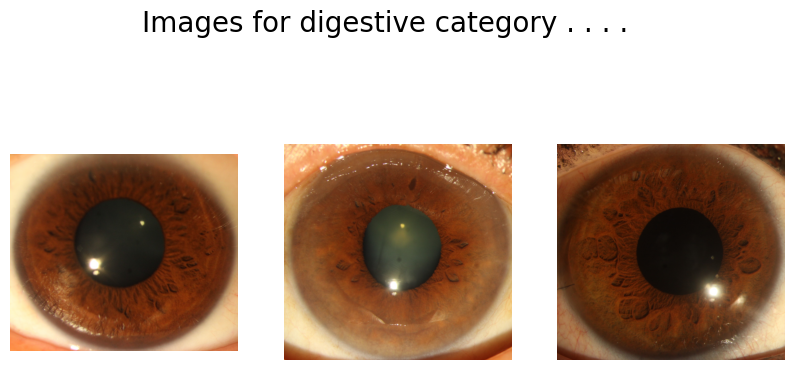

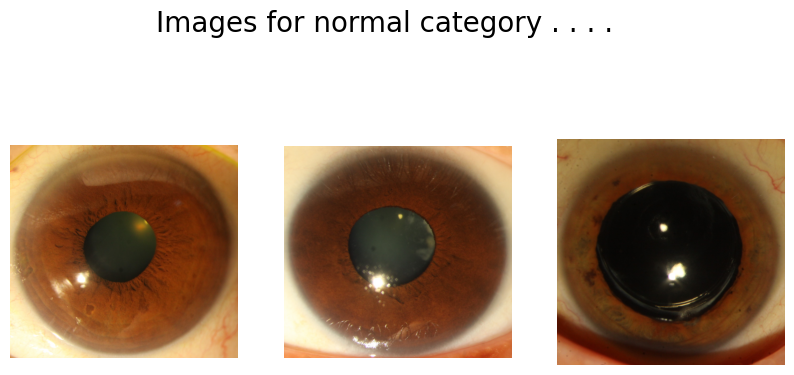

In [14]:
path = '/content/drive/MyDrive/Research/New folder'
classes = ['digestive', 'normal']

#display the images choosing randomly in lungs classes
for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    fig.suptitle(f'Images for {cat} category . . . .', fontsize=20)

    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{path}/{cat}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

In [25]:
IMG_SIZE = 256
SPLIT = 0.2
EPOCHS = 20
BATCH_SIZE = 64

X = []
Y = []

for i, cat in enumerate(classes):
  images = glob(f'{path}/{cat}/*.JPG')

  for image in images:
    img = cv2.imread(image)

    X.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
    Y.append(i)

X = np.asarray(X)
one_hot_encoded_Y = pd.get_dummies(Y).values

#split the data set into train and validation
X_train, X_val, Y_train, Y_val = train_test_split(X, one_hot_encoded_Y, test_size=SPLIT, random_state=2022)

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

Training samples: 141, Validation samples: 36


In [26]:
# ==========================================
# 3. HYBRID MODEL (MobileNetV2 + DenseNet121)
# ==========================================
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Branch A: MobileNetV2 (Lightweight feature extractor)
base_mobile = MobileNetV2(input_tensor=input_layer, include_top=False, weights='imagenet')
base_mobile.trainable = False
a = layers.GlobalAveragePooling2D()(base_mobile.output)

# Branch B: DenseNet121 (Powerful feature reuse)
base_dense = DenseNet121(input_tensor=input_layer, include_top=False, weights='imagenet')
base_dense.trainable = False
b = layers.GlobalAveragePooling2D()(base_dense.output)

# Concatenate Features
combined = layers.Concatenate()([a, b])

# Classification Head
x = layers.Dense(512, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(len(classes), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

/tmp/ipython-input-1357752864.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobile = MobileNetV2(input_tensor=input_layer, include_top=False, weights='imagenet')


In [27]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
# ==========================================
# 4. TRAINING
# ==========================================
# Callbacks
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

In [29]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 101s 31s/step - accuracy: 0.3907 - loss: 1.1954 - val_accuracy: 0.4722 - val_loss: 1.5372
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.5555 - loss: 1.0028 - val_accuracy: 0.4722 - val_loss: 1.0467
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 0.5121 - loss: 0.9509 - val_accuracy: 0.5833 - val_loss: 0.7693
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.5951 - loss: 0.7852 - val_accuracy: 0.6667 - val_loss: 0.6521
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 0.6457 - loss: 0.8296 - val_accuracy: 0.6667 - val_loss: 0.6107
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.6771 - loss: 0.6667 - val_accuracy: 0.6111 - val_loss: 0.5970
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.6732 - loss: 0.7045 - val_accuracy: 0.6389 - val_loss: 0.5953
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.7227 - loss: 0.6461 - val_accuracy: 0.6944 - val_loss:

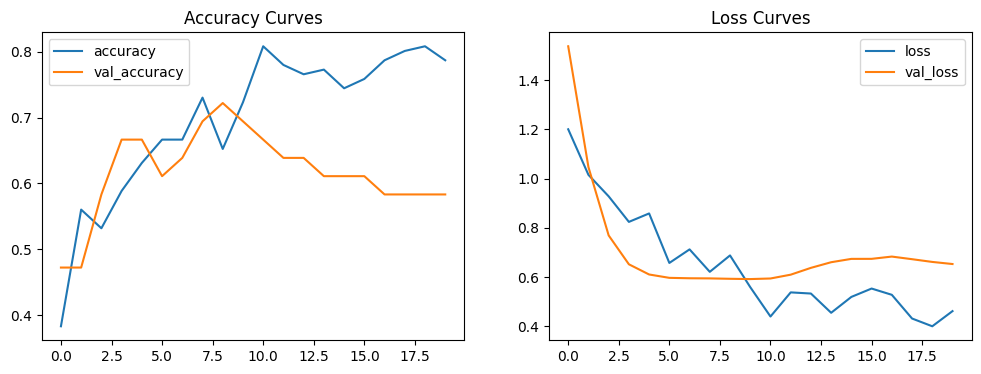

1/2 ━━━━━━━━━━━━━━━━━━━━ 18s 19s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 47s 29s/step
              precision    recall  f1-score   support

   digestive       0.54      0.88      0.67        17
      normal       0.75      0.32      0.44        19

    accuracy                           0.58        36
   macro avg       0.64      0.60      0.56        36
weighted avg       0.65      0.58      0.55        36



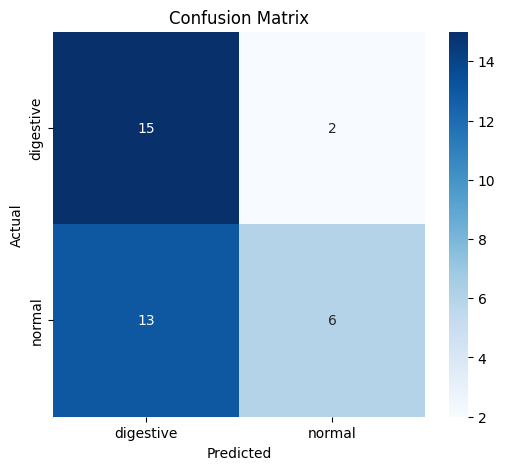

In [30]:
# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
# Plot Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df = pd.DataFrame(history.history)

history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')

history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

# Confusion Matrix
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
print(classification_report(Y_true, Y_pred_classes, target_names=classes))
plt.title('Confusion Matrix')
plt.show()